In [48]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [49]:
from brian2 import *
import functions as fc

In [ ]:
simtime1 = 1*10**3 * ms

In [63]:
data = np.load('analysis_a.npz')

In [64]:
cv_dist_E = fc.get_isi_cv(N=800, spike_trains=SpikeTrainsE, t_min=0*ms, t_max=1000*ms)
mean_cv_E = np.mean(cv_dist_E)

In [65]:
spike_corr = fc.get_spike_correlation(spike_trains=SpikeTrainsE, t_min=0*ms, t_max=simtime1, bin_size=10*ms, N=800)

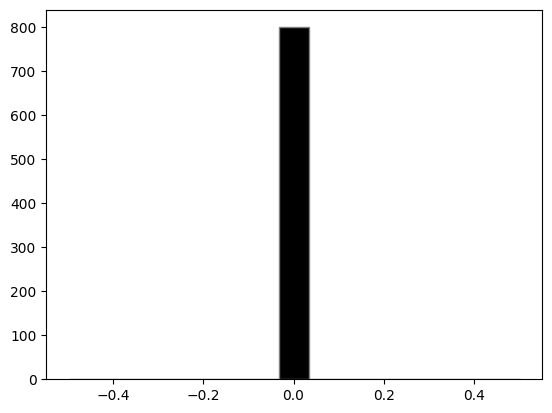

In [45]:
plt.hist(spike_corr, bins=15, color='black', edgecolor='grey', alpha=1)
plt.show()

In [46]:
from matplotlib.gridspec import GridSpec

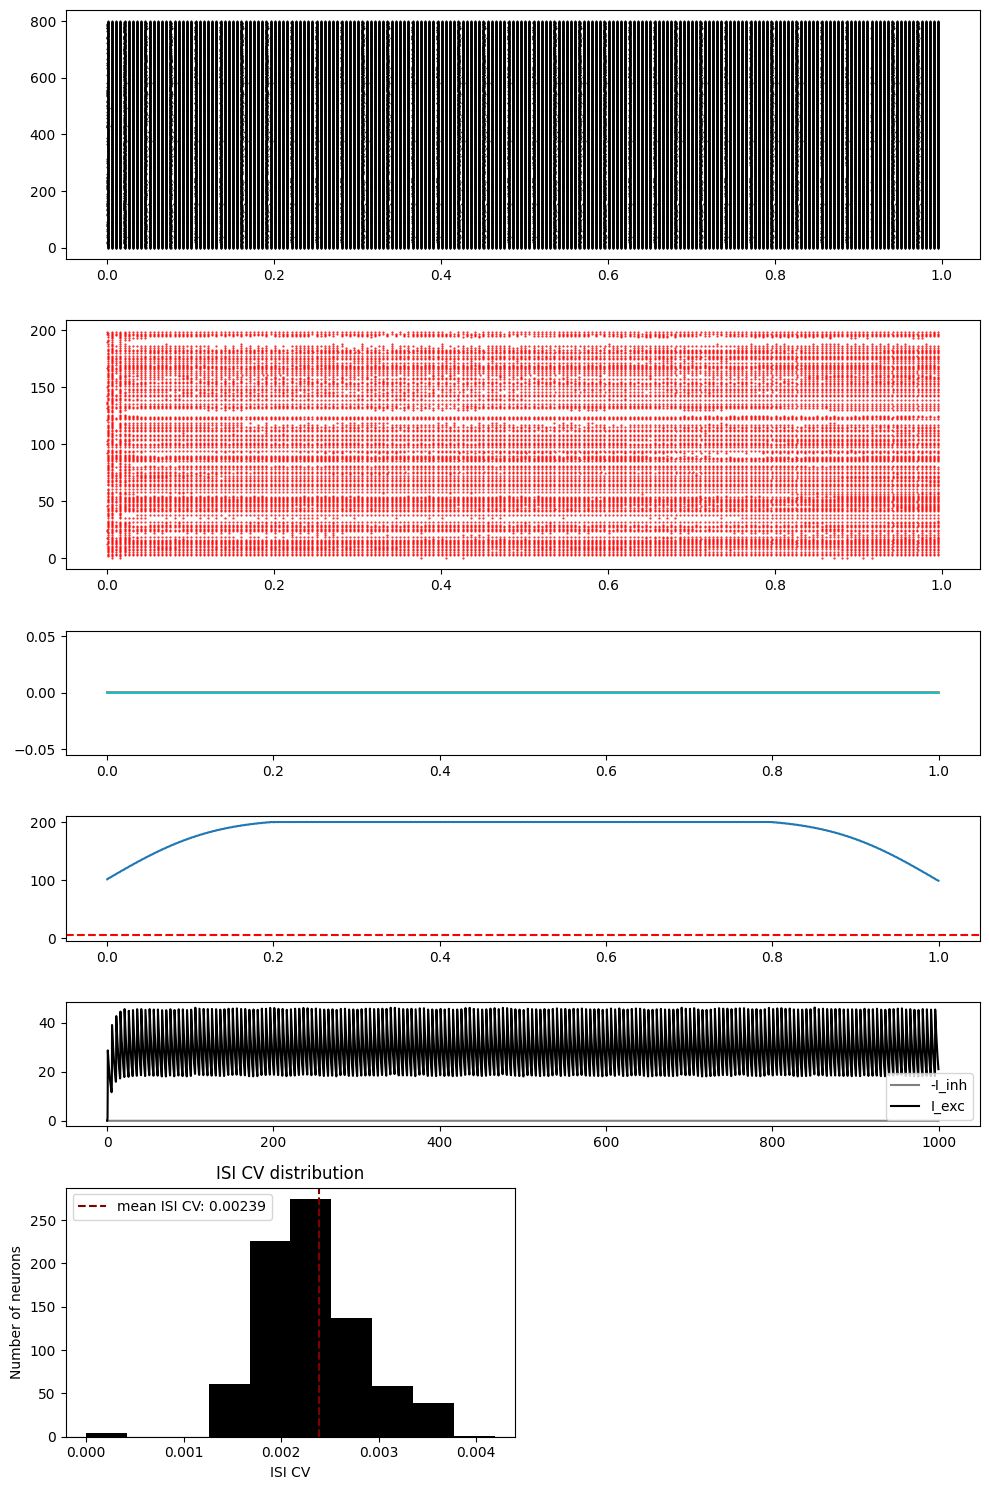

In [47]:
fig = plt.figure(figsize=(10, 15))
gs = GridSpec(6, 2, figure=fig, height_ratios=[1, 1, 0.5, 0.5, 0.5, 1])  

ax1 = fig.add_subplot(gs[0, :])
ax1.plot(SpikeMonE.t, SpikeMonE.i, '.k', ms=1)

ax2 = fig.add_subplot(gs[1, :])
ax2.plot(SpikeMonI.t, SpikeMonI.i, '.r', ms=1)

ax3 = fig.add_subplot(gs[2, :])
ax3.plot(SynMon.t, SynMon.w.T)

ax4 = fig.add_subplot(gs[3, :])
ax4.plot(RateMonE.t, RateMonE.smooth_rate(window="gaussian", width=100*ms) / Hz)
ax4.axhline(5, linestyle='--', color='red')


ax5 = fig.add_subplot(gs[4, :])
ax5.plot(CurrentMon.t / ms, CurrentMon.I_inh[0] / nA, color='grey', label='-I_inh')
ax5.plot(CurrentMon.t / ms, CurrentMon.I_exc[0] / nA, color='black', label='I_exc')
ax5.legend()

ax6 = fig.add_subplot(gs[5, 0])
ax6.hist(cv_dist_E, bins=10, color='black', alpha=1)
ax6.axvline(mean_cv_E, color='maroon', ls='--', label=f'mean ISI CV: {np.round(mean_cv_E, 5)}')
ax6.axhline(0, color='k', lw=0.8)
ax6.set_xlabel('ISI CV')
ax6.set_ylabel('Number of neurons')
ax6.set_title('ISI CV distribution')
ax6.legend()

plt.tight_layout()
plt.show()